## **1. Import Libraries**
---

In [ ]:
# Download ICDAR 2003 dataset
# https://drive.google.com/file/d/1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV/view
!gdown 1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV
!unzip -q icdar2003.zip -d datasets

Downloading...
From (original): https://drive.google.com/uc?id=1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV
From (redirected): https://drive.google.com/uc?id=1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV&confirm=t&uuid=3424c935-08fd-4491-aa75-75dce4fc8a0d
To: /kaggle/working/icdar2003.zip
100%|██████████████████████████████████████| 45.7M/45.7M [00:00<00:00, 96.0MB/s]


In [3]:
import os
import json
import yaml
import shutil
import xml.etree.ElementTree as ET

import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import ultralytics
from ultralytics import YOLO

ultralytics.checks()

Ultralytics 8.3.85 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6170.0/8062.4 GB disk)


## **2. Prepare Data**
---

In [4]:
def extract_data_from_xml(path):
    tree = ET.parse(path)
    root = tree.getroot()

    img_paths, img_sizes, img_labels, bounding_boxes = [], [], [], []
    for image in root:
        bbs_of_image    = []
        labels_of_image = []

        for bbs in image.findall('taggedRectangles'):
            for bb in bbs:
                
                # Skip false bouding box
                if not bb[0].text.isalnum():
                    continue
                if "é" in bb[0].text.lower() or "ñ" in bb[0].text.lower():
                    continue

                # Save valid bouding box
                bbs_of_image.append([
                    float(bb.attrib["x"]),
                    float(bb.attrib["y"]),
                    float(bb.attrib["width"]),
                    float(bb.attrib["height"]),
                ])
                labels_of_image.append(bb[0].text.lower())

        img_paths.append(image[0].text)
        img_sizes.append((int(image[1].attrib["x"]), int(image[1].attrib["y"])))
        bounding_boxes.append(bbs_of_image)
        img_labels.append(labels_of_image)

    return img_paths, img_sizes, img_labels, bounding_boxes

In [5]:
dataset_dir    = 'datasets/SceneTrialTrain'
words_xml_path = os.path.join(dataset_dir, 'words.xml')
img_paths, img_sizes, img_labels, bounding_boxes = extract_data_from_xml(words_xml_path)

print(f"Number of images      : {len(img_paths)}")
print(f"Example image path    : {img_paths[0]}")
print(f"Example image size    : {img_sizes[0]}")
print(f"Example bounding boxes: {bounding_boxes[0][:2]}")
print(f"Example labels        : {img_labels[0][:2]}")

Number of images      : 250
Example image path    : apanar_06.08.2002/IMG_1261.JPG
Example image size    : (1600, 1200)
Example bounding boxes: [[174.0, 392.0, 274.0, 195.0], [512.0, 391.0, 679.0, 183.0]]
Example labels        : ['self', 'adhesive']


In [6]:
def convert_to_yolo_format(img_paths, img_sizes, bounding_boxes):
    yolo_data = []
    for image_path, image_size, bboxes in zip(img_paths, img_sizes, bounding_boxes):
        image_width, image_height = image_size

        yolo_labels = []
        for bbox in bboxes:
            x, y, w, h = bbox

            # Recalculate bounding box coordinates to fit YOLO format
            center_x          = (x + w / 2) / image_width
            center_y          = (y + h / 2) / image_height
            normalized_width  = w / image_width
            normalized_height = h / image_height

            # No specific label in this task
            class_id = 0

            # Convert
            yolo_label = f"{class_id} {center_x} {center_y} {normalized_width} {normalized_height}"
            yolo_labels.append(yolo_label)

        yolo_data.append((image_path, yolo_labels))

    return yolo_data

In [7]:
yolo_data = convert_to_yolo_format(img_paths, img_sizes, bounding_boxes)

## **3. Create Dataset**
---

In [8]:
def save_data(data, src_img_dir, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(os.path.join(save_dir, 'images'), exist_ok=True)
    os.makedirs(os.path.join(save_dir, 'labels'), exist_ok=True)

    for image_path, yolo_labels in data:
        shutil.copy(
            os.path.join(src_img_dir, image_path), 
            os.path.join(save_dir, 'images')
        )

        image_name = os.path.basename(image_path)
        image_name = os.path.splitext(image_name)[0]

        with open(os.path.join(save_dir, 'labels', f"{image_name}.txt"), 'w') as f:
            for label in yolo_labels:
                f.write(f"{label}\n")

In [9]:
train_data, test_data = train_test_split(yolo_data, test_size=0.2  , random_state=0, shuffle=True)
test_data, val_data   = train_test_split(test_data, test_size=0.125, random_state=0, shuffle=True)

save_yolo_data_dir = 'datasets/yolo_data'
os.makedirs(save_yolo_data_dir, exist_ok=True)

save_train_dir = os.path.join(save_yolo_data_dir, 'train')
save_val_dir   = os.path.join(save_yolo_data_dir, 'val')
save_test_dir  = os.path.join(save_yolo_data_dir, 'test')

save_data(train_data, dataset_dir, save_train_dir)
save_data(test_data, dataset_dir, save_val_dir)
save_data(val_data, dataset_dir, save_test_dir)

In [10]:
class_labels = ['text']

data_yaml = {
    'train': 'train/images',
    'test' : 'test/images',
    'val'  : 'val/images',
    'nc'   : 1,
    'names': class_labels,
}

yolo_yaml_path = os.path.join(save_yolo_data_dir, 'data.yml')
with open(yolo_yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

## **4. Create YOLOv11 Model | Training & Evaluation**
---

In [11]:
model = YOLO('yolo11m.pt')

100%|██████████| 38.8M/38.8M [00:00<00:00, 250MB/s]


In [12]:
results = model.train(
    data=os.path.join(os.getcwd(), 'datasets/yolo_data/data.yml'),
    epochs=100,
    imgsz=640,
    cache=True,
    patience=20,
    plots=True,
)

Ultralytics 8.3.85 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11m.pt, data=/kaggle/working/datasets/yolo_data/data.yml, epochs=100, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, cache=True, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=

100%|██████████| 755k/755k [00:00<00:00, 17.9MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  1    111872  ultralytics.nn.modules.block.C3k2            [128, 256, 1, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  1    444928  ultralytics.nn.modules.block.C3k2            [256, 512, 1, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  1   1380352  ultralytics.nn.modules.block.C3k2            [512, 512, 1, True]           
  7                  -1  1   2360320  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 74.4MB/s]


AMP: checks passed ✅


...


100 epochs completed in 0.268 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 40.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 40.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.85 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m summary (fused): 125 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.92it/s]


                   all         43        200      0.885      0.935      0.933      0.734


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 10.6ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/detect/train


In [13]:
model_path = 'runs/detect/train/weights/best.pt'
model      = YOLO(model_path)
metrics    = model.val()

Ultralytics 8.3.85 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m summary (fused): 125 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs


val: Scanning /kaggle/working/datasets/yolo_data/val/labels.cache... 43 images, 2 backgrounds, 0 corrupt: 100%|██████████| 43/43 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  1.73it/s]


                   all         43        200      0.888      0.935      0.934      0.734


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 3.6ms preprocess, 24.2ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to runs/detect/val


## **5. Inference**
---

In [14]:
def visualize_bbox(img_path, predictions, conf_thres=0.8, font=cv2.FONT_HERSHEY_SIMPLEX):
    img  = cv2.imread(img_path)
    h, w = img.shape[:2]

    for prediction in predictions:
        conf_score = prediction['confidence']
        if conf_score < conf_thres:
            continue

        bbox = prediction['box']
        xmin = int(bbox['x1'])
        ymin = int(bbox['y1'])
        xmax = int(bbox['x2'])
        ymax = int(bbox['y2'])
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)

        text = f"{conf_score:.2f}"
        (text_width, text_height), _ = cv2.getTextSize(text, font, 1, 2)
        cv2.rectangle(
            img,
            (xmin, ymin - text_height - 5),
            (xmin + text_width, ymin),
            (0, 255, 0),
            -1,
        )
        cv2.putText(img, text, (xmin, ymin - 5), font, 1, (0, 0, 0), 2)

    return img

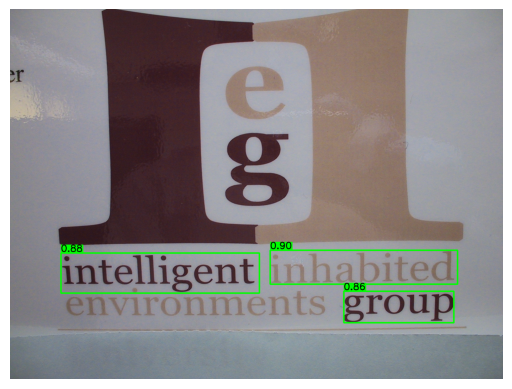

In [15]:
model_path = 'runs/detect/train/weights/best.pt'
img_path   = 'datasets/SceneTrialTrain/apanar_06.08.2002/IMG_1247.JPG'
conf_thres = 0.75
model      = YOLO(model_path)

# Run inference
results        = model(img_path, verbose=False)
predictions    = json.loads(results[0].to_json())
visualized_img = visualize_bbox(img_path, predictions, conf_thres)

%matplotlib inline
plt.imshow(visualized_img)
plt.axis("off")
plt.show()